MDS-UPDRS Part III → Motor Examination

Movement Disorder Society–Unified Parkinson’s Disease Rating Scale

- NP3TOT = Total score of MDS-UPDRS Part III

NP3 → refers to Part III (motor examination) of the MDS-UPDRS
TOT → total (sum of all items in that section)

This is the clinician-rated motor exam, measuring things like:

- Tremor
- Rigidity
- Finger tapping / hand movements
- Gait and balance
- Posture
- Bradykinesia (slowness)

In [6]:
import pandas as pd

df = pd.read_csv("MDS-UPDRS_Part_III_27Mar2026.csv")

print(df.head())
print(df.columns)
print(df.shape)

      REC_ID  PATNO EVENT_ID PAG_NAME   INFODT  PDTRTMNT PDSTATE  HRPOSTMED  \
0  272451901   3000       BL  NUPDRS3  02/2011       NaN     NaN        NaN   
1  338703101   3000      V04  NUPDRS3  03/2012       NaN     NaN        NaN   
2  385009801   3000      V06  NUPDRS3  02/2013       NaN     NaN        NaN   
3  437131401   3000      V08  NUPDRS3  03/2014       NaN     NaN        NaN   
4  512469901   3000      V10  NUPDRS3  03/2015       NaN     NaN        NaN   

   HRDBSON  HRDBSOFF  ...  NP3RTARL  NP3RTALL  NP3RTALJ  NP3RTCON  NP3TOT  \
0      NaN       NaN  ...       0.0       0.0       0.0       0.0     4.0   
1      NaN       NaN  ...       0.0       0.0       0.0       0.0     1.0   
2      NaN       NaN  ...       0.0       0.0       0.0       0.0     4.0   
3      NaN       NaN  ...       0.0       0.0       0.0       0.0     2.0   
4      NaN       NaN  ...       0.0       0.0       0.0       0.0    19.0   

   DYSKPRES DYSKIRAT  NHY  ORIG_ENTRY          LAST_UPDATE  
0

C:\Users\sheru\AppData\Local\Temp\ipykernel_14112\257677957.py:3: DtypeWarning: Columns (16,21) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("MDS-UPDRS_Part_III_27Mar2026.csv")


In [7]:
df = df[[
    "PATNO",     # patient ID
    "EVENT_ID",  # visit label
    "INFODT",    # visit date
    "NP3TOT"     # severity score
]]

In [8]:
df

,PATNO,EVENT_ID,INFODT,NP3TOT
0,3000,BL,02/2011,4.0
1,3000,V04,03/2012,1.0
2,3000,V06,02/2013,4.0
3,3000,V08,03/2014,2.0
4,3000,V10,03/2015,19.0
...,...,...,...,...
37199,572491,BL,02/2026,4.0
37200,573011,BL,02/2026,5.0
37201,573011,BL,02/2026,NaN
37202,623134,BL,03/2026,9.0


In [ ]:
# convert to datetime
df["INFODT"] = pd.to_datetime(df["INFODT"])

C:\Users\sheru\AppData\Local\Temp\ipykernel_14112\3417844781.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["INFODT"] = pd.to_datetime(df["INFODT"])


In [10]:
# remove missing severity score

df = df.dropna(subset=["NP3TOT"])

In [11]:
# sort based on patient id and visit date

df = df.sort_values(["PATNO", "INFODT"])

In [ ]:
# create longitudinal time variable

df["baseline_date"] = df.groupby("PATNO")["INFODT"].transform("min")

df["time_days"] = (df["INFODT"] - df["baseline_date"]).dt.days

df["time_months"] = df["time_days"] / 30.44


In [20]:
df["time_years"] = df["time_months"] / 12

In [15]:
# Remove patients with only one visit

visit_counts = df.groupby("PATNO").size()

df = df[df["PATNO"].isin(visit_counts[visit_counts >= 2].index)]

In [17]:
print("Patients:", df["PATNO"].nunique())
print("Rows:", len(df))
print(df.head())

Patients: 3914
Rows: 29340
   PATNO EVENT_ID     INFODT  NP3TOT baseline_date  time_days  time_months
0   3000       BL 2011-02-01     4.0    2011-02-01          0     0.000000
1   3000      V04 2012-03-01     1.0    2011-02-01        394    12.943495
2   3000      V06 2013-02-01     4.0    2011-02-01        731    24.014455
3   3000      V08 2014-03-01     2.0    2011-02-01       1124    36.925099
4   3000      V10 2015-03-01    19.0    2011-02-01       1489    48.915900


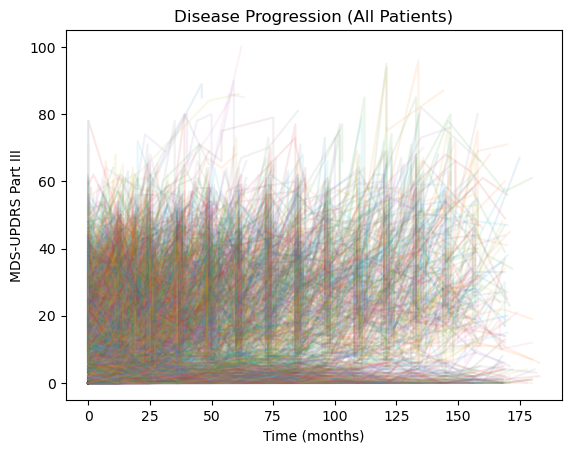

In [18]:
import matplotlib.pyplot as plt

for pid, group in df.groupby("PATNO"):
    plt.plot(group["time_months"], group["NP3TOT"], alpha=0.1)

plt.xlabel("Time (months)")
plt.ylabel("MDS-UPDRS Part III")
plt.title("Disease Progression (All Patients)")
plt.show()

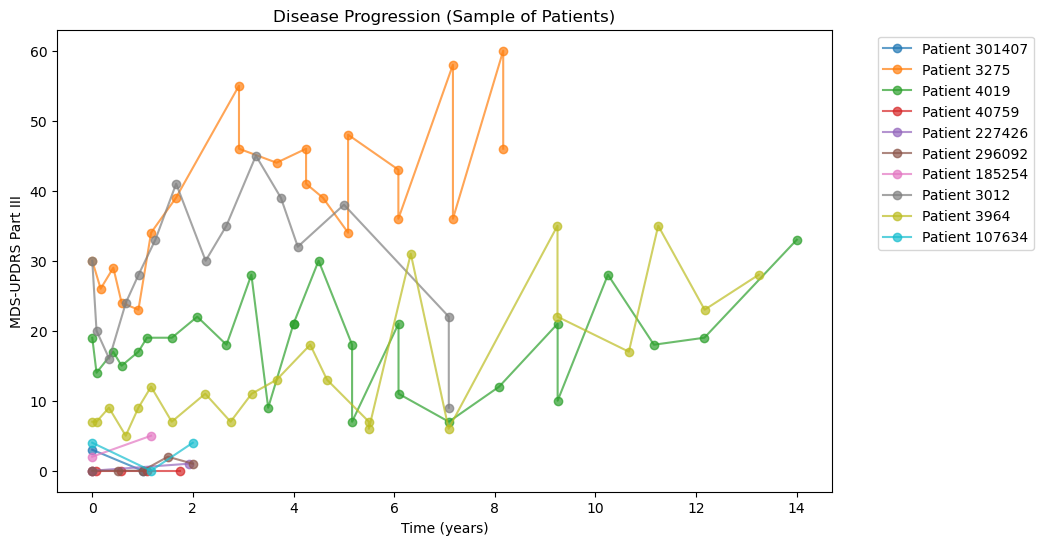

In [49]:
import numpy as np
import matplotlib.pyplot as plt

sample_patients = np.random.choice(df["PATNO"].unique(), 10, replace=False)

plt.figure(figsize=(10,6))

for pid in sample_patients:
    sub = df[df["PATNO"] == pid]
    plt.plot(sub["time_years"], sub["NP3TOT"], marker="o", alpha=0.7, label=f"Patient {pid}")

plt.xlabel("Time (years)")
plt.ylabel("MDS-UPDRS Part III")
plt.title("Disease Progression (Sample of Patients)")

plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")  
plt.show()


In [50]:
sample_patients

array([301407,   3275,   4019,  40759, 227426, 296092, 185254,   3012,
         3964, 107634], dtype=int64)

In [51]:
pid = [301407,   3275,   4019,  40759, 227426, 296092, 185254,   3012,
         3964, 107634]
df[df["PATNO"].isin(pid)]



,PATNO,EVENT_ID,INFODT,NP3TOT,baseline_date,time_days,time_months,time_years,time_bin
165,3012,SC,2011-10-01,30.0,2011-10-01,0,0.000000,0.000000,0.0
164,3012,BL,2011-11-01,20.0,2011-10-01,31,1.018397,0.084866,0.0
167,3012,V01,2012-02-01,16.0,2011-10-01,123,4.040736,0.336728,0.0
166,3012,ST,2012-06-01,24.0,2011-10-01,244,8.015769,0.667981,1.0
168,3012,V03,2012-09-01,28.0,2011-10-01,336,11.038108,0.919842,1.0
...,...,...,...,...,...,...,...,...,...
35229,296092,V04,2025-03-01,0.0,2024-03-01,365,11.990802,0.999233,1.0
35230,296092,V05,2025-09-01,2.0,2024-03-01,549,18.035480,1.502957,2.0
35231,296092,V06,2026-03-01,1.0,2024-03-01,730,23.981603,1.998467,2.0
35335,301407,BL,2024-06-01,3.0,2024-06-01,0,0.000000,0.000000,0.0


Why mixed modeling for disease progression?

Measurements from the same patient are correlated (not independent)

Mixed models let you capture both:

- Fixed effects → overall population trend
(e.g., average worsening per year)
- Random effects → individual differences
(e.g., some patients decline faster/slower)

In this project:
- Fixed effect → average motor decline per year
- Random effect → each patient’s own baseline + slope

This is crucial because disease progression is highly variable across people

In [24]:
import statsmodels.formula.api as smf

model = smf.mixedlm(
    "NP3TOT ~ time_years",
    df,
    groups=df["PATNO"],
    re_formula="~time_years"
)

result = model.fit()

print(result.summary())

              Mixed Linear Model Regression Results
Model:                MixedLM   Dependent Variable:   NP3TOT      
No. Observations:     29340     Method:               REML        
No. Groups:           3914      Scale:                43.8947     
Min. group size:      2         Log-Likelihood:       -103825.0075
Max. group size:      35        Converged:            Yes         
Mean group size:      7.5                                         
------------------------------------------------------------------
                        Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------
Intercept               11.439    0.185 61.852 0.000 11.076 11.801
time_years               0.827    0.040 20.545 0.000  0.748  0.906
Group Var              117.099    0.483                           
Group x time_years Cov   3.496    0.065                           
time_years Var           2.040    0.017                           



Disease severity, measured by MDS-UPDRS Part III, increased significantly over time, with an average progression rate of approximately 0.83 points per year.”

Group Var (Intercept variance) = 117.099

some patients start mild
some start severe

Time slope variance = 2.040

i.e. Patients progress at different speeds

Meaning:

- some worsen quickly
- some stay stable
- some may even improve

- Disease worsens over time BUT not uniformly
- There is high heterogeneity across patients

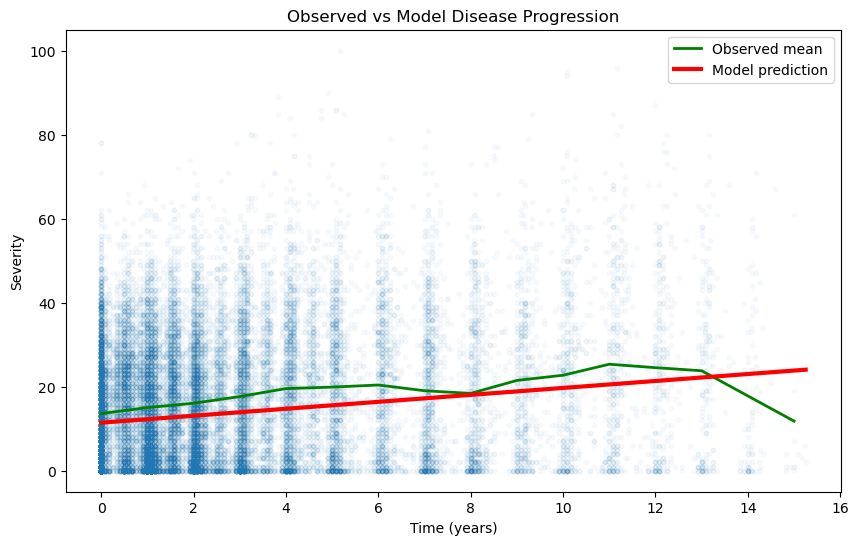

In [53]:
df["time_bin"] = df["time_years"].round()

mean_traj = df.groupby("time_bin")["NP3TOT"].mean().reset_index()

plt.figure(figsize=(10,6))

plt.scatter(df["time_years"], df["NP3TOT"], alpha=0.03, s=10)

plt.plot(
    mean_traj["time_bin"],
    mean_traj["NP3TOT"],
    color="green",
    linewidth=2,
    label="Observed mean"
)

plt.plot(
    pred_df["time_years"],
    pred_df["predicted"],
    color="red",
    linewidth=3,
    label="Model prediction"
)

plt.xlabel("Time (years)")
plt.ylabel("Severity")
plt.title("Observed vs Model Disease Progression")
plt.legend()
plt.show()